##Introducción

Los incendios forestales no son solo un dato más, son un fenómeno que impacta directamente ecosistemas, biodiversidad y comunidades. Cuando la Comisión Nacional Forestal (CONAFOR) publicó el registro oficial de incendios forestales de 2025, quise responder una pregunta concreta: ¿qué estados concentran mayor impacto, qué tipo de vegetación es más vulnerable, y qué está causando realmente estos incendios?

Trabajé el dataset (7,016 registros, 76 variables) en dos etapas: primero en Python (Google Colab), donde limpié y validé la información tales como fechas, duplicados, consistencia de categorías para posteriormente trabajar en Power BI, donde construí un dashboard interactivo para explorar los hallazgos por estado, tipo de vegetación, causa y evolución a lo largo del año.

## 1. Carga y exploración inicial

In [1]:
from google.colab import files

# Sube el archivo Excel desde tu ordenador
# Se abrirá un cuadro de diálogo para que selecciones el archivo
uploaded = files.upload()

Saving 2025_Incendios_forestales.csv to 2025_Incendios_forestales.csv


In [2]:
import pandas as pd
file_name = list(uploaded.keys())[0] # Obtiene el nombre del primer archivo subido
df = pd.read_csv(file_name)
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df.head()

,anio,semana,consecutivo,clave_incendio,tipo_atencion,ifae,longitud_grados,longitud_minutos,longitud_segundos,latitud_grados,...,helicoptero,cantidad,instancias_equipo_aereo,dron,intermunicipal,intermunicipal1,interestatal,interestatal1,clave_interestatal,crmf
0,2025,4,1,25-01-0001,Combate,Incendio Forestal,102,11,10.28,21,...,0,0,0,0,0,NaN,0,NaN,0,Occidente
1,2025,4,2,25-01-0002,Combate,Incendio Forestal,102,16,6.56,21,...,0,0,0,0,0,NaN,0,NaN,0,Occidente
2,2025,5,3,25-01-0003,Combate,Incendio Forestal,102,29,14.68,21,...,0,0,0,0,0,NaN,0,NaN,0,Occidente
3,2025,6,4,25-01-0004,Combate,Incendio Forestal,102,25,17.01,21,...,0,0,0,0,0,NaN,0,NaN,0,Occidente
4,2025,6,5,25-01-0005,Combate,Incendio Forestal,101,58,27.20,22,...,0,0,0,0,0,NaN,0,NaN,0,Occidente


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7016 entries, 0 to 7015
Data columns (total 76 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   anio                              7016 non-null   int64  
 1   semana                            7016 non-null   int64  
 2   consecutivo                       7016 non-null   int64  
 3   clave_incendio                    7016 non-null   object 
 4   tipo_atencion                     7016 non-null   object 
 5   ifae                              7016 non-null   object 
 6   longitud_grados                   7016 non-null   int64  
 7   longitud_minutos                  7016 non-null   int64  
 8   longitud_segundos                 7016 non-null   float64
 9   latitud_grados                    7016 non-null   int64  
 10  latitud_minutos                   7016 non-null   int64  
 11  latitud_segundos                  7016 non-null   float64
 12  cve_mu

## 2. Limpieza de fechas

In [5]:
print('Registros duplicados:', df.duplicated().sum())

Registros duplicados: 0


In [6]:
#cambio formato fecha en las columnas fecha inicio y fecha liquidacion
df['fecha_inicio'] = pd.to_datetime(df['fecha_inicio'], errors="coerce")
df['fecha_liquidacion'] = pd.to_datetime(df['fecha_liquidacion'], errors="coerce")

/tmp/ipykernel_5397/3169804988.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['fecha_inicio'] = pd.to_datetime(df['fecha_inicio'], errors="coerce")
/tmp/ipykernel_5397/3169804988.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['fecha_liquidacion'] = pd.to_datetime(df['fecha_liquidacion'], errors="coerce")


In [7]:
print('Fechas inválidas en fecha_inicio:', df['fecha_inicio'].isna().sum())
print('Fechas inválidas en fecha_liquidacion:', df['fecha_liquidacion'].isna().sum())

Fechas inválidas en fecha_inicio: 0
Fechas inválidas en fecha_liquidacion: 0


In [8]:
#Validación del cambio
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7016 entries, 0 to 7015
Data columns (total 76 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   anio                              7016 non-null   int64         
 1   semana                            7016 non-null   int64         
 2   consecutivo                       7016 non-null   int64         
 3   clave_incendio                    7016 non-null   object        
 4   tipo_atencion                     7016 non-null   object        
 5   ifae                              7016 non-null   object        
 6   longitud_grados                   7016 non-null   int64         
 7   longitud_minutos                  7016 non-null   int64         
 8   longitud_segundos                 7016 non-null   float64       
 9   latitud_grados                    7016 non-null   int64         
 10  latitud_minutos                   7016 non-null 

##3. Análisis: incidencia y superficie afectada

In [9]:
#Revisar registros validos del estado
df['entidad'].value_counts()

,count
entidad,
Jalisco,919
México,796
Michoacán,682
Chihuahua,596
Ciudad De México,512
Durango,411
Guerrero,304
Puebla,303
Chiapas,287


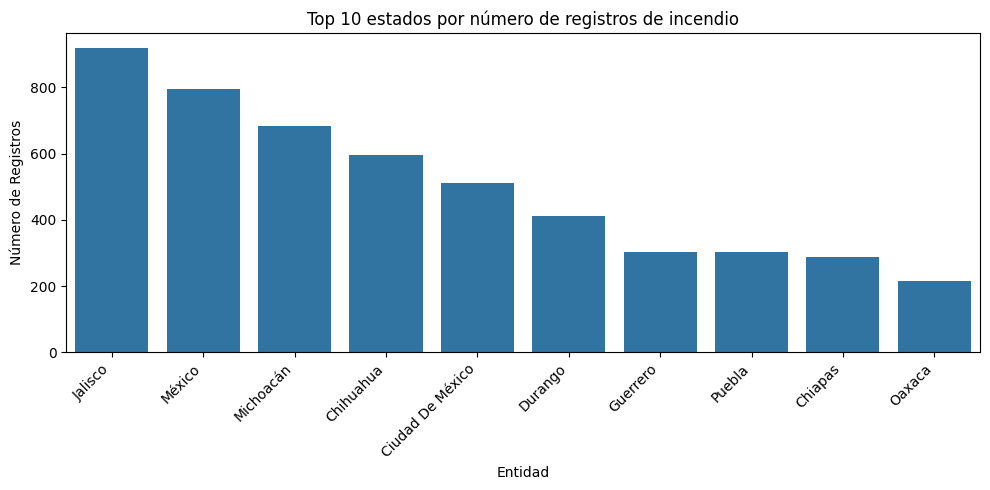

In [10]:
plt.figure(figsize=(10,5))
entidad_counts = df['entidad'].value_counts().reset_index(name='total_registros')
sns.barplot(data=entidad_counts.sort_values(by='total_registros', ascending=False).head(10),
            x='entidad', y='total_registros')
plt.title('Top 10 estados por número de registros de incendio')
plt.xlabel('Entidad')
plt.ylabel('Número de Registros')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
#Determinar la superficie afectada por estado
df.groupby('entidad')['total_ha'].sum().reset_index().sort_values(by='total_ha', ascending=False)

,entidad,total_ha
5,Chihuahua,221533.3043
24,Sinaloa,106815.4396
11,Guerrero,104580.6386
9,Durango,103402.3068
13,Jalisco,88821.8709
26,Tabasco,79260.4174
17,Nayarit,67770.8530
1,Baja California,55434.5629
3,Campeche,51980.3234
25,Sonora,48527.8651


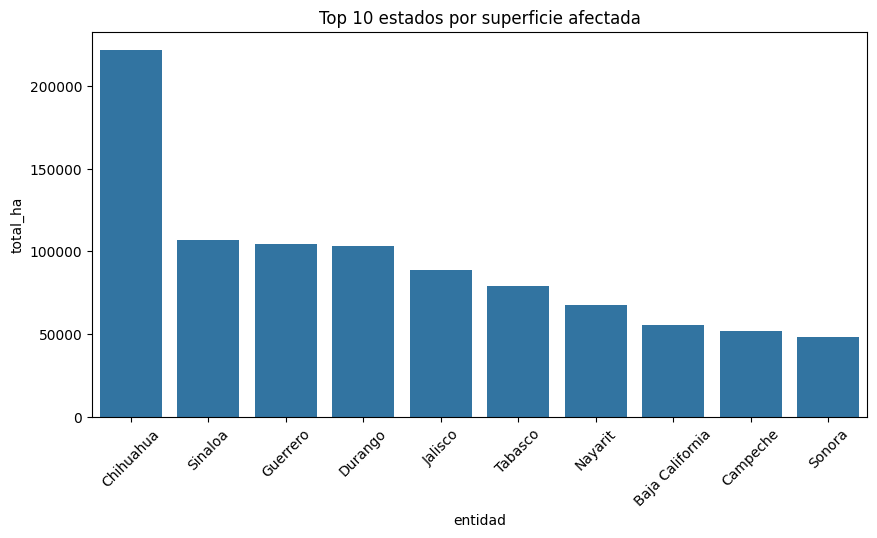

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(data=df.groupby('entidad')['total_ha'].sum().reset_index().sort_values('total_ha', ascending=False).head(10),
            x='entidad', y='total_ha')
plt.title('Top 10 estados por superficie afectada')
plt.xticks(rotation=45)
plt.show()

In [13]:
#Superficie ha total incendiada en México
print(f"Superficie total incendiada en México (2025): {df['total_ha'].sum():,.0f} hectáreas")

Superficie total incendiada en México (2025): 1,230,212 hectáreas


## 4. Análisis: causas de incendio

In [14]:
#Validar registros de las causas de incendio
df['posible_causa'].value_counts()

,count
posible_causa,
Desconocidas,2361
Actividades agrícolas,1539
Intencional,1337
Actividades pecuarias,545
Fogatas,365
Fumadores,287
Cazadores,146
Quema de basureros,135
Naturales,95


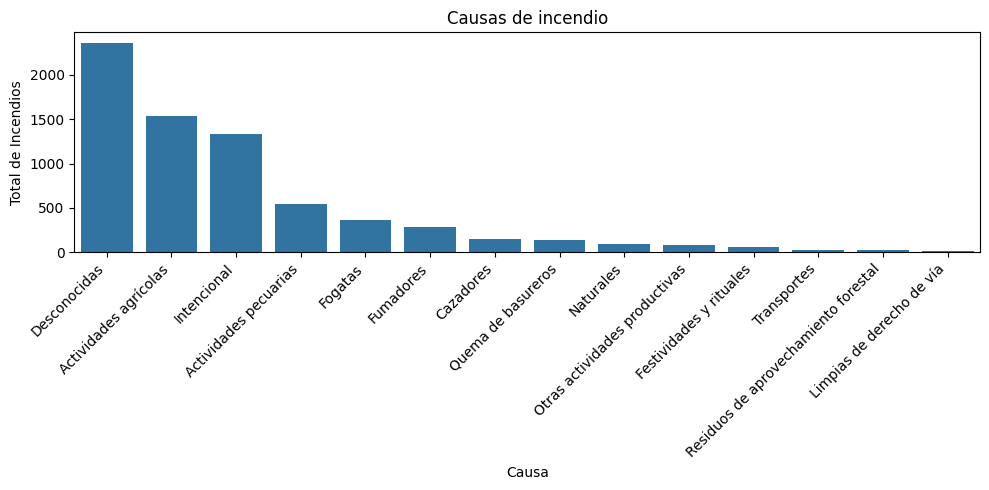

In [15]:
plt.figure(figsize=(10,5))
causas_incendio = df['posible_causa'].value_counts().reset_index(name='total_incendios')
sns.barplot(data=causas_incendio.sort_values(by='total_incendios', ascending=False),
            x='posible_causa', y='total_incendios')
plt.title('Causas de incendio')
plt.xlabel('Causa')
plt.ylabel('Total de Incendios')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Análisis: tipo de vegetación afectada

In [16]:
#Validar los registros por tipo de vegetación
df['tipo_vegetacion'].value_counts()

,count
tipo_vegetacion,
Bosque de Pino,1978
Bosque de Pino-Encino,1084
Bosque de Encino,1077
Selva Baja Caducifolia,877
Bosque de Encino-Pino,379
Matorral Crasicaule,267
Pastizal Natural,164
Tular,161
Bosque Cultivado,108


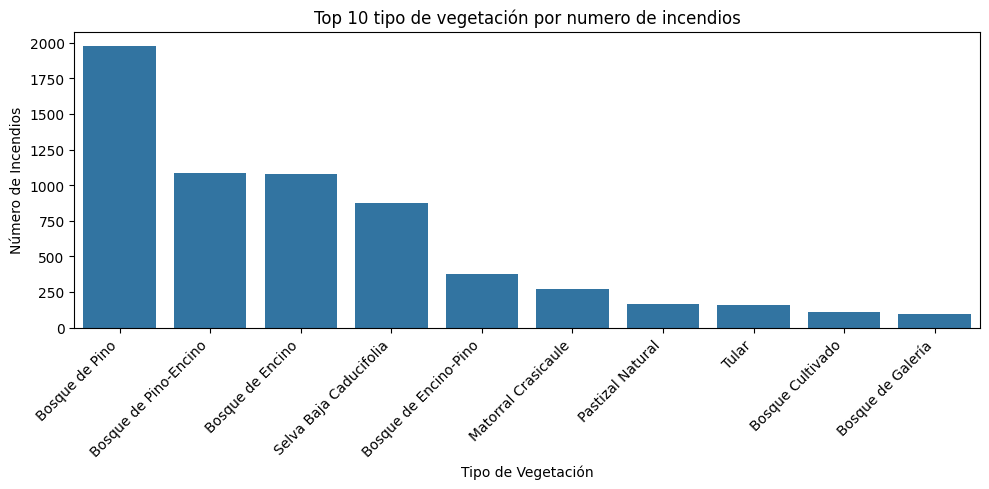

In [17]:
plt.figure(figsize=(10,5))
vegetacion_counts = df['tipo_vegetacion'].value_counts().reset_index(name='count')
sns.barplot(data=vegetacion_counts.head(10),
            x='tipo_vegetacion', y='count')
plt.title('Top 10 tipo de vegetación por numero de incendios')
plt.xlabel('Tipo de Vegetación')
plt.ylabel('Número de Incendios')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Análisis: duración vs. superficie afectada

In [18]:
# ¿Los incendios que duran más días son los que más superficie consumen?
orden_duracion = ['1 Día', '2 a 3 Días', '4 a 7 Días', 'Mayor de 7 Días']

duracion_superficie = df.groupby('categoria_duracion_dias')['total_ha'].agg(['sum', 'mean', 'count']).reindex(orden_duracion)
duracion_superficie.columns = ['superficie_total_ha', 'superficie_promedio_ha', 'num_incendios']
duracion_superficie

,superficie_total_ha,superficie_promedio_ha,num_incendios
categoria_duracion_dias,,,
1 Día,64128.8150,18.218413,3520
2 a 3 Días,182802.6322,86.065269,2124
4 a 7 Días,265479.0021,299.299890,887
Mayor de 7 Días,717801.8181,1480.003749,485


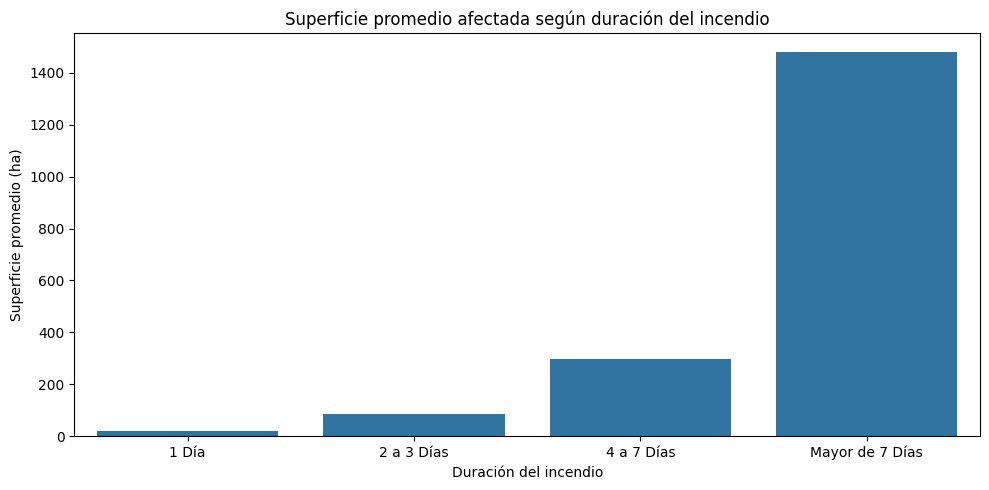

In [19]:
# Visualización: superficie promedio afectada por categoría de duración
plt.figure(figsize=(10,5))
sns.barplot(data=duracion_superficie.reset_index(),
            x='categoria_duracion_dias', y='superficie_promedio_ha',
            order=orden_duracion)
plt.title('Superficie promedio afectada según duración del incendio')
plt.xlabel('Duración del incendio')
plt.ylabel('Superficie promedio (ha)')
plt.tight_layout()
plt.show()

In [20]:
# Superficie total concentrada en incendios de larga duración
porcentaje_larga_duracion = duracion_superficie.loc['Mayor de 7 Días', 'superficie_total_ha'] / df['total_ha'].sum() * 100
porcentaje_incendios_larga_duracion = duracion_superficie.loc['Mayor de 7 Días', 'num_incendios'] / len(df) * 100

print(f"Los incendios de más de 7 días representan el {porcentaje_incendios_larga_duracion:.1f}% del total de incendios,")
print(f"pero concentran el {porcentaje_larga_duracion:.1f}% de toda la superficie afectada en 2025.")

Los incendios de más de 7 días representan el 6.9% del total de incendios,
pero concentran el 58.3% de toda la superficie afectada en 2025.


##6. Conclusiones

Con base al analisis realizado a la base de datos "Incendios forestales 2025" de la CONAFOR, se obtuvo que:
* En total se registraron 7,016 incendios en México durante el año 2025.
* La superficie afectada fue de 1,230,212 hectáreas.
* El estado de Chihuahua es la entidad que mayor afectación tuvo por superficie incendiada.
* De las 32 entidades de Méxcio, Jalisco encabeza con 919 incendios, seguido de México (796) y Michoacán (682).
* El tipo de vegetación mayormente afectado fue Bosque de Pino (1,978 registros), seguido de Bosque de Pino-Encino y Bosque de Encino.
* En total 2361 registros de los incendios son de causa desconocida, pero de los identificados, actividades agrícolas (1,539) e intencionales (1,337) dominan por mucho sobre causas naturales (solo 95). La mayoría de los incendios forestales en México en 2025 no son naturales, son antropogénicos.
*Los incendios con duración mayor a 7 días representan solo el 7% del total, pero concentran el 58% de toda la superficie afectada en 2025 — con un promedio de 1,480 hectáreas por incendio, frente a apenas 18 hectáreas en los que se resuelven en un solo día. Esto sugiere que la velocidad de respuesta y contención inicial es un factor crítico para limitar el impacto real de un incendio forestal.

In [22]:
df.to_csv('incendios_2025_limpio.csv', index=False)